In [1]:
# Load the libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/simulated_fake_transactions_dataset_2.csv')
df.head()

,Date,Timestamp,Account No,Balance,Amount,Third Party Account No,Third Party Name
0,01/01/2025,00:00,839964633.0,3385.0,2602.0,NaN,Boots
1,01/01/2025,00:00,793069740.0,3318.0,2780.0,NaN,Mountain Warehouse
2,01/01/2025,00:00,793069740.0,2278.0,-1040.0,705519819.0,NaN
3,01/01/2025,00:00,705519819.0,2726.0,1040.0,793069740.0,NaN
4,01/01/2025,00:00,726302171.0,3253.5,1542.5,NaN,Craftastic


### Check for Missing Values

In [4]:
missing_values = df[["Account No", "Balance", "Amount"]].isnull().sum()
print(missing_values)

Account No    311
Balance       285
Amount        309
dtype: int64


### Handling Missing Values

In [6]:
# Dropping rows where 'Account No' is missing
df_cleaned = df.dropna(subset=["Account No"]).copy()

# Fill missing balance
df_cleaned['Balance'] = df_cleaned.groupby('Account No')['Balance'].ffill()
df_cleaned['Balance'] = df_cleaned['Balance'].fillna(df_cleaned['Balance'].median())

# Fill missing 'Amount' values with 0 (assuming no transaction occurred)
df_cleaned['Amount'] = df_cleaned['Amount'].fillna(0)

# Drop rows where 'Date' or 'Timestamp' is missing 
df_cleaned = df_cleaned.dropna(subset=['Date', 'Timestamp'])

# Fill 'Third Party Account No' with 'Unknown' since many transactions may not have them
df_cleaned['Third Party Account No'] = df_cleaned['Third Party Account No'].fillna("Unknown")

# Fill 'Third Party Name' with 'Unknown'
df_cleaned['Third Party Name'] = df_cleaned['Third Party Name'].fillna("Unknown")

# Check if missing values remain
print(df_cleaned.isnull().sum())

Date                      0
Timestamp                 0
Account No                0
Balance                   0
Amount                    0
Third Party Account No    0
Third Party Name          0
dtype: int64


### Feature Engineering 

In [8]:
# Convert 'Date' and 'Timestamp' columns to datetime format
df_cleaned['Datetime'] = pd.to_datetime(df_cleaned['Date'] + ' ' + df_cleaned['Timestamp'], errors='coerce')

In [9]:
# Extract useful time-based features
df_cleaned['Year'] = df_cleaned['Datetime'].dt.year
df_cleaned['Month'] = df_cleaned['Datetime'].dt.month 
df_cleaned['Day'] = df_cleaned['Datetime'].dt.day 
df_cleaned['Hour'] = df_cleaned['Datetime'].dt.hour 
df_cleaned['DayOfWeek'] = df_cleaned['Datetime'].dt.dayofweek # Mon=0 --- Sun=6
# Sort values by Datetime for time-series modeling
df_cleaned = df_cleaned.sort_values(by = ['Datetime'])

# Drop the other columns as they are irrelevant
# df_cleaned = df_cleaned.drop(columns = ['Date', 'Timestamp'])

# display processed dataset
print(df_cleaned.head())

            Date Timestamp   Account No  Balance   Amount  \
0     01/01/2025     00:00  839964633.0  3385.00  2602.00   
3917  01/01/2025     00:00  790253866.0  1657.01    -5.99   
3916  01/01/2025     00:00  893840914.0   606.06    -7.99   
3915  01/01/2025     00:00  893840914.0   614.05    -7.99   
3914  01/01/2025     00:00  893840914.0   622.04   -12.99   

     Third Party Account No Third Party Name   Datetime    Year  Month  Day  \
0                   Unknown            Boots 2025-01-01  2025.0    1.0  1.0   
3917                Unknown   Mojang Studios 2025-01-01  2025.0    1.0  1.0   
3916                Unknown           Disney 2025-01-01  2025.0    1.0  1.0   
3915                Unknown           Amazon 2025-01-01  2025.0    1.0  1.0   
3914                Unknown       SquareOnix 2025-01-01  2025.0    1.0  1.0   

      Hour  DayOfWeek  
0      0.0        2.0  
3917   0.0        2.0  
3916   0.0        2.0  
3915   0.0        2.0  
3914   0.0        2.0  


### Data Preparation for Model Training

In [11]:
# create target variable (future balance)
df_cleaned['Future_Balance'] = df_cleaned.groupby('Account No')['Balance'].shift(-1)

# drop rows where Future_Balance is missing (last transaction of each account)
df_cleaned = df_cleaned.dropna()

# Define feature columns (X) and target column (y)
features = ['Balance', 'Amount', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']
X = df_cleaned[features]
y = df_cleaned['Future_Balance']

# display the dataset
print(X.head(), y.head())

      Balance   Amount    Year  Month  Day  Hour  DayOfWeek
0     3385.00  2602.00  2025.0    1.0  1.0   0.0        2.0
3917  1657.01    -5.99  2025.0    1.0  1.0   0.0        2.0
3916   606.06    -7.99  2025.0    1.0  1.0   0.0        2.0
3915   614.05    -7.99  2025.0    1.0  1.0   0.0        2.0
3914   622.04   -12.99  2025.0    1.0  1.0   0.0        2.0 0       2611.02
3917    1642.02
3916     614.05
3915     622.04
3914     635.03
Name: Future_Balance, dtype: float64


In [12]:
from sklearn.model_selection import train_test_split

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes confirming split
print("Training set size: ", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size:  (87502, 7)
Testing set size:  (21876, 7)


### Model Training to Predict Future Balance

In [14]:
# Import the libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [15]:
# Initializing the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

# Print evaluation metrics
print(f"Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared (R2): {r2:.4f}")

Model Performance Metrics:
Mean Absolute Error (MAE): 729.48
Mean Squared Error (MSE): 1549730.62
Root Mean Squared Error (RMSE): 1244.88
R-Squared (R2): 0.8306


### Training a Random Forest Model

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Initialise Random Forest Model
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42, n_jobs = -1)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Displaying the metrics
print(f"Random Forest Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-Squared (R2): {r2_rf:.4f}")

Random Forest Model Performance Metrics:
Mean Absolute Error (MAE): 680.00
Mean Squared Error (MSE): 1211531.94
Root Mean Squared Error (RMSE): 1100.70
R-Squared (R2): 0.8676


### Training an XGBoost Model

In [19]:
from xgboost import XGBRegressor

# Initialise XGBoost Model
xgb_model = XGBRegressor(n_estimators = 200, learning_rate = 0.1, random_state = 42, n_jobs = -1)

# Train the model
xgb_model.fit(X_train, y_train)

# Make Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Displaying the metrics
print(f"XGBoost Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-Squared (R2): {r2_xgb:.4f}")

XGBoost Model Performance Metrics:
Mean Absolute Error (MAE): 643.54
Mean Squared Error (MSE): 1141166.78
Root Mean Squared Error (RMSE): 1068.25
R-Squared (R2): 0.8753


| **Model** | **MAE** | **MSE** | **RMSE** | **R$^2$**|
|-----------|---------|---------|----------|----------|
| **Linear Regression** | 729.48 | 1549730.62 | 1244.88 | 0.8306 |
| **Random Forest** | 680.0 | 1211531.94 | 1100.70 | 0.8676 |
| **XGBoost** | 643.54 | 1141166.78 | 1068.25 | 0.8753 |86768676306


### Hyperparameter Tuning for XGBoost

In [22]:
# Hyperparameter-tuned model
xgb_tuned = XGBRegressor(n_estimators = 300, 
                         learning_rate = 0.05, 
                         max_depth = 6, 
                         subsample = 0.8, 
                         colsample_bytree = 0.8, 
                         random_state = 42, n_jobs = -1)

# Train the model
xgb_tuned.fit(X_train, y_train)

# Make Predictions
y_pred_xgb_tuned = xgb_tuned.predict(X_test)

# Evaluate the model
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

# Displaying the metrics
print(f"Tuned XGBoost Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae_xgb_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_tuned:.2f}")
print(f"R-Squared (R2): {r2_xgb_tuned:.4f}")

Tuned XGBoost Model Performance Metrics:
Mean Absolute Error (MAE): 646.22
Mean Squared Error (MSE): 1136706.68
Root Mean Squared Error (RMSE): 1066.16
R-Squared (R2): 0.8758


|**MODEL**|**MAE**|**MSE**|**RMSE**|**R$^2$**|
|-----|---|---|----|---|
|**Initial XGBoost**|643.54|1141166.78|1068.25|0.8753|
|**Tuned XGBoost**|**646.22**|**1136706.68**|**1066.16**|**0.8758**|

* The **R$^2$ improved slightly**, indicating a marginal increase in accuracy.
* **MSE and RMSE decreased**, meaning fewer extreme errors.
* However, **MAE increased slightly**, suggesting minor trade-offs in absolute error.

### Feature Importance Analysis & Forecasting

C:\Users\snand\AppData\Local\Temp\ipykernel_21576\680081125.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = feature_importances, y = feature_names, palette = "viridis")


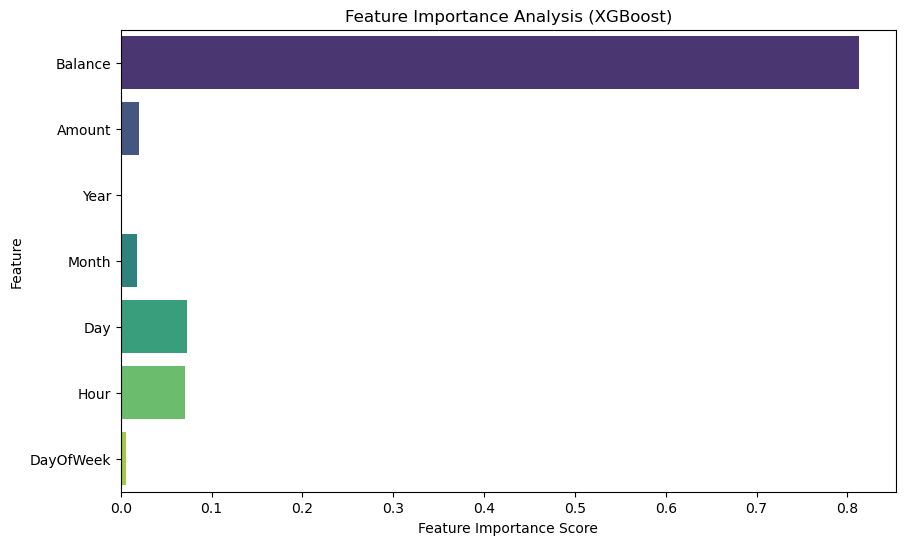

In [25]:
# Feature Importance from XGBoost
feature_importances = xgb_tuned.feature_importances_
feature_names = X_train.columns

# Plot feature importance
plt.figure(figsize = (10, 6))
sns.barplot(x = feature_importances, y = feature_names, palette = "viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance Analysis (XGBoost)")
plt.show()


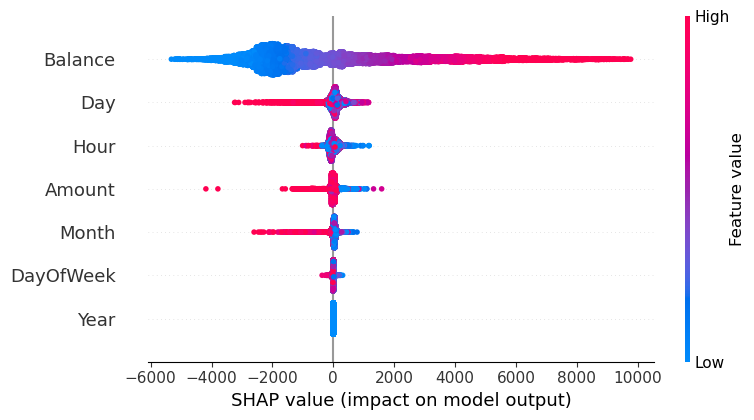

In [26]:
import shap

# SHAP Analysis
explainer = shap.Explainer(xgb_tuned)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

#### Inference
1. **Feature Importance**
   * **Balance** is the most influential factor in predicting future balance. It dominates the model's decision-making process.
   * **Amount** has a very low impact, most likely because it's just a single transaction value and not an accumulated measure.
   * **Date-based features (Month, Day, Hour, DayOfWeek, and Year)** contribute minimally, but they still help capture seasonal trends.
  
2. **SHAP**
   * **Balance has the highest impact** on predictions, shown by the spread of SHAP values.
   * **High feature values (red) tend to push predictions higher**, while **low values (blue) push them lower**.
   * **Day & Hour show some effect,** possibly capturing transaction patterns at specific times.
   * **Amount has mixed influence**, suggesting its effect varies depending on balance and time-based features. 

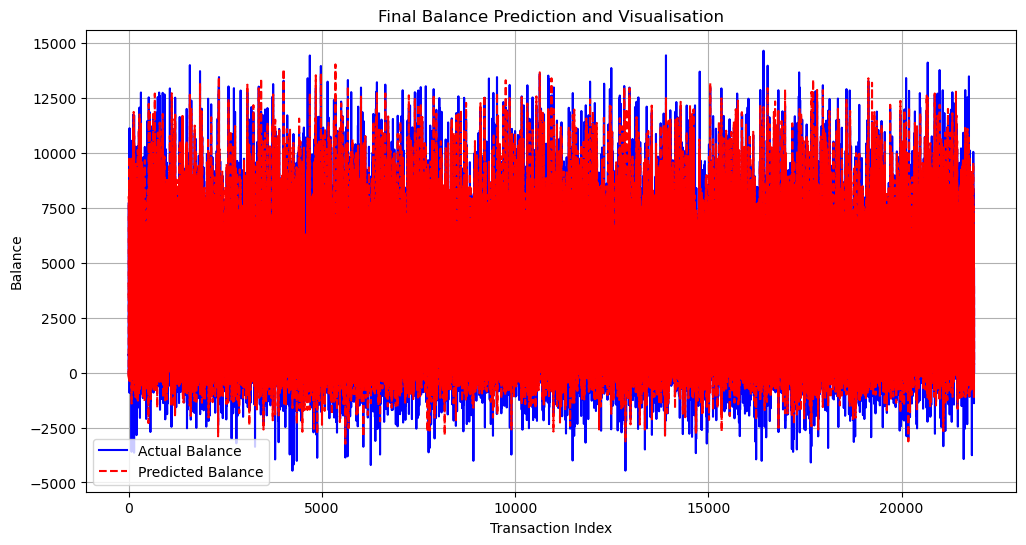

In [28]:
# Forecast & Visualisation
future_balances = xgb_tuned.predict(X_test)

# Visualisation
plt.figure(figsize = (12, 6))
plt.plot(y_test.values, label = "Actual Balance", color = "Blue")
plt.plot(future_balances, label = "Predicted Balance", color = "Red", linestyle = "dashed")
plt.xlabel("Transaction Index")
plt.ylabel("Balance")
plt.title("Final Balance Prediction and Visualisation")
plt.legend()
plt.grid()
plt.show()

#### Inference
1. **High Overlap between actual and predicted values** - The model performs well in tracking balance changes, but the prediction line (red) is densely packed.
2. **High Volatility in balances** - There is significant fluctuation, indicating that transactional behavior varies widely.

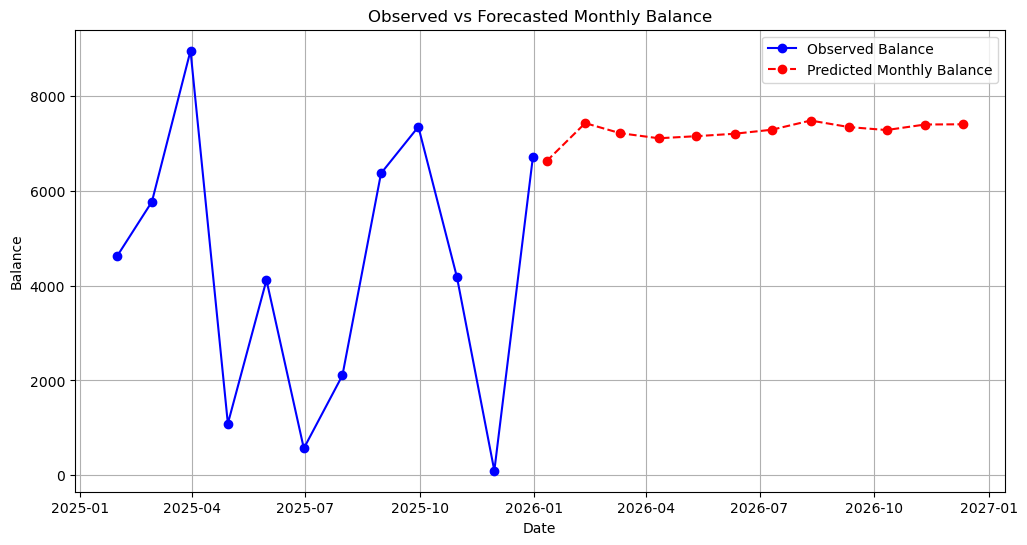

In [30]:
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date']) # ensuring Date is in correct format
last_known_date = df_cleaned['Date'].max()

# aggregate balance per month for historical data
df_monthly = df_cleaned.resample('ME', on = 'Date').agg({'Balance': 'last'}).reset_index()
# define future months (next 12 months)
future_steps = 12 
future_dates = [last_known_date + pd.DateOffset(months = i) for i in range(1, future_steps +1)]
future_df = pd.DataFrame({'Date': future_dates})

# extract date features for the new data
future_df['Year'] = future_df['Date'].dt.year
future_df['Month'] = future_df['Date'].dt.month
future_df['Day'] = 1 # Assuming transactions happen at the start of the month
future_df['Hour'] = 0 # placeholder
future_df['DayOfWeek'] = future_df['Date'].dt.dayofweek

# use the last known balance for rolling predictions
last_balance = df_cleaned['Balance'].iloc[-1]
future_df['Balance'] = last_balance
future_df['Amount'] = 0 # Assuming no new transaction trends

# select relevant features
future_X = future_df[['Balance', 'Amount', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']]

# Predict future balances
future_df['Predicted_Balance'] = xgb_tuned.predict(future_X)

# Plot future monthly forecast
plt.figure(figsize = (12, 6))

# plot historical balance
plt.plot(df_monthly['Date'], df_monthly['Balance'], color = 'blue', label = 'Observed Balance', marker = 'o')

# plot predicted balance
plt.plot(future_df['Date'], future_df['Predicted_Balance'], marker = 'o', linestyle = "dashed", color = "red", label = "Predicted Monthly Balance")

plt.xlabel("Date")
plt.ylabel("Balance")
plt.title("Observed vs Forecasted Monthly Balance")
plt.legend()
plt.grid()
plt.show()

#### Inference
* The observed data (blue) shows **high volatility**, with frequent sharp increases and decreases in balance.
* The forecasted data (red) is **much smoother**, suggesting that the model is predicting a more stable trend rather than large fluctuations.
* The predicted balance **does not capture extreme variations** seen in historical data, which may indicate that the model is averaging out fluctuations rather than precisely predicting them.

In [32]:
# Print column names to check if 'Date' exists
print(df_cleaned.columns)

# If 'Date' is missing, check the DataFrame structure
print(df_cleaned.head())


Index(['Date', 'Timestamp', 'Account No', 'Balance', 'Amount',
       'Third Party Account No', 'Third Party Name', 'Datetime', 'Year',
       'Month', 'Day', 'Hour', 'DayOfWeek', 'Future_Balance'],
      dtype='object')
           Date Timestamp   Account No  Balance   Amount  \
0    2025-01-01     00:00  839964633.0  3385.00  2602.00   
3917 2025-01-01     00:00  790253866.0  1657.01    -5.99   
3916 2025-01-01     00:00  893840914.0   606.06    -7.99   
3915 2025-01-01     00:00  893840914.0   614.05    -7.99   
3914 2025-01-01     00:00  893840914.0   622.04   -12.99   

     Third Party Account No Third Party Name   Datetime    Year  Month  Day  \
0                   Unknown            Boots 2025-01-01  2025.0    1.0  1.0   
3917                Unknown   Mojang Studios 2025-01-01  2025.0    1.0  1.0   
3916                Unknown           Disney 2025-01-01  2025.0    1.0  1.0   
3915                Unknown           Amazon 2025-01-01  2025.0    1.0  1.0   
3914                Unk

In [33]:
print(df_cleaned.index.dtype)   # Check if it's datetime, integer, or object
print(df_cleaned.index[:10])    # Print first few index values
print(df_cleaned.index[-10:])   # Print last few index values

int64
Index([0, 3917, 3916, 3915, 3914, 3913, 3912, 3911, 3910, 3918], dtype='int64')
Index([262500, 262501, 262502, 262503, 262504, 262505, 262506, 262507, 262508,
       262509],
      dtype='int64')


In [34]:
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])  # Convert to datetime if needed
df_cleaned.set_index('Date', inplace=True)               # Set as index
df_cleaned = df_cleaned.sort_index()                     # Ensure chronological order
print(df_cleaned.index[:10])
print(df_cleaned.index[-10:])
print(df_cleaned.index.inferred_freq)  # See if there's a regular pattern

DatetimeIndex(['2025-01-01', '2025-01-01', '2025-01-01', '2025-01-01',
               '2025-01-01', '2025-01-01', '2025-01-01', '2025-01-01',
               '2025-01-01', '2025-01-01'],
              dtype='datetime64[ns]', name='Date', freq=None)
DatetimeIndex(['2025-12-11', '2025-12-11', '2025-12-11', '2025-12-11',
               '2025-12-11', '2025-12-11', '2025-12-11', '2025-12-11',
               '2025-12-11', '2025-12-11'],
              dtype='datetime64[ns]', name='Date', freq=None)
None


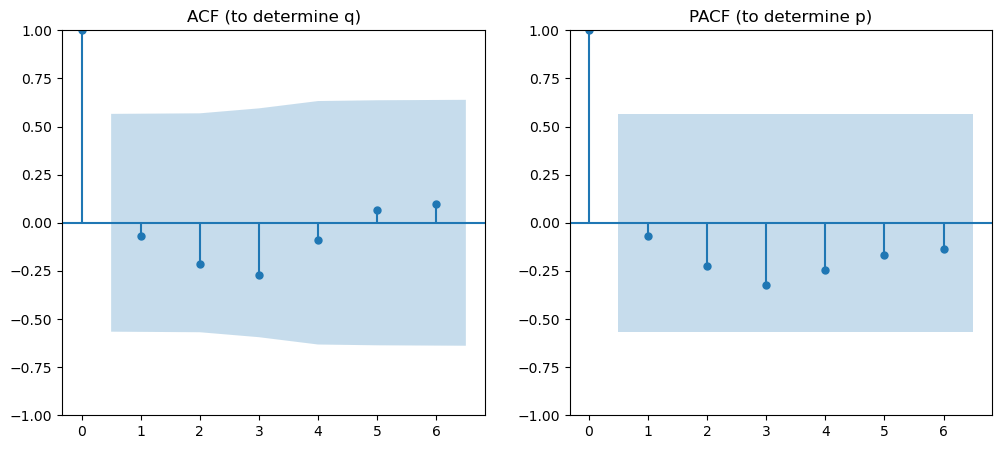

ADF Statistic:  -3.126386770249563
p-value:  0.024661081527528772
Data is stationary


In [35]:
import warnings
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

# Convert index to Datetime and set as index
df_cleaned['Datetime'] = pd.to_datetime(df_cleaned.index)
df_cleaned.set_index('Datetime', inplace=True)

# Resample to Monthly Balance
df_monthly = df_cleaned['Balance'].resample('ME').last().dropna()

# Check for unique values
if df_monthly.nunique() == 1:
    print("All values in df_monthly are constant. ADF test is not needed (already stationary).")
else:
    # Check if there are enough data points for ACF/PACF
    if len(df_monthly) > 2:
        max_lags = min(10, len(df_monthly) // 2)

        # Plot ACF & PACF
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        sm.graphics.tsa.plot_acf(df_monthly, lags=max_lags, ax=ax[0])
        ax[0].set_title("ACF (to determine q)")
        sm.graphics.tsa.plot_pacf(df_monthly, lags=max_lags, ax=ax[1])
        ax[1].set_title("PACF (to determine p)")
        plt.show()
    else:
        print("Not enough data to plot ACF/PACF. Require more than 2 observations.")

    # Run ADF Test if data is variable
    adf_test = adfuller(df_monthly)
    print("ADF Statistic: ", adf_test[0])
    print("p-value: ", adf_test[1])

    # Inference
    if adf_test[1] < 0.05:
        print("Data is stationary")
    else:
        print("Data is non-stationary (Further Differencing is required)")


#### Inference
* The lags in ACF/PACF don't drop to zero immediately, this indicates potential **trend components**.

In [37]:
import itertools
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# Define parameter range
p = q = range(0, 3)
d = [0]
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None

# Iterate over all combinations
for order in pdq:
    try:
        model = ARIMA(df_monthly, order=order)
        model_fit = model.fit()
        aic = model_fit.aic  # AIC score (lower is better)
        if aic < best_aic:
            best_aic = aic
            best_order = order
    except:
        continue

print(f"Best ARIMA Order: {best_order} with AIC: {best_aic}")


Best ARIMA Order: (0, 0, 0) with AIC: 228.03379773338787


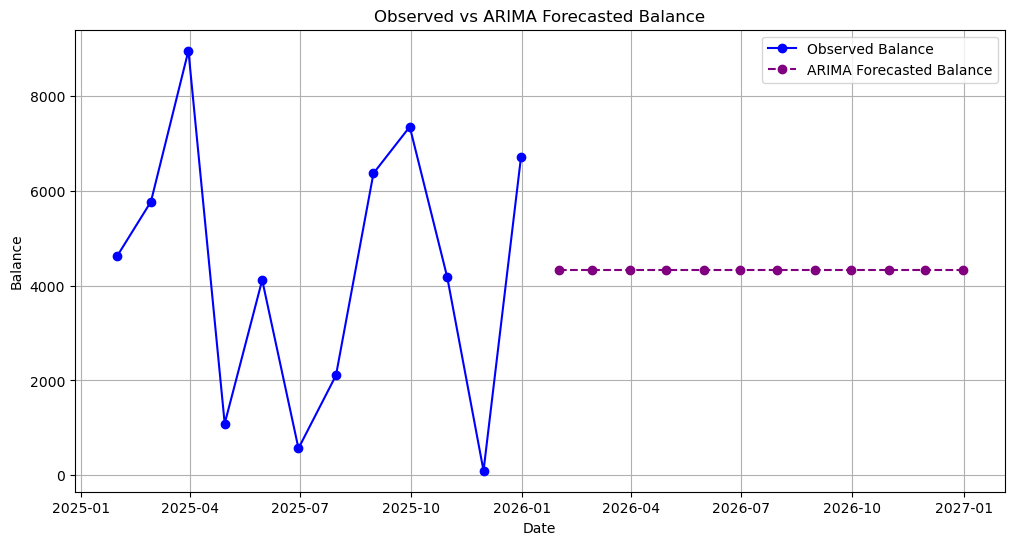

In [38]:
import pmdarima as pm

# df_cleaned['Datetime'] = pd.to_datetime(df_cleaned.index)
# df_cleaned.set_index('Datetime', inplace = True)

# resample to monthly balance
# df_monthly = df_cleaned['Balance'].resample('ME').last().dropna()

# use auto_arima to find best (p, d, q)
# auto_model = pm.auto_arima(df_monthly, seasonal = False, stepwise = True, trace = True)

# Get best parameters
# best_order = auto_model.order
# print(f"Optimal ARIMA Order: {best_order}")
# best_order = (0, 1, 1)

# fit the model
model = ARIMA(df_monthly, order = best_order)
model_fit = model.fit()

# forecast future months
future_steps = 12
forecast = model_fit.forecast(steps = future_steps)

# create data range for forecast
future_dates = pd.date_range(start = df_monthly.index[-1], periods = future_steps + 1, freq = 'ME')[1:]

# convert forecast to dataframe
forecast_df = pd.DataFrame({'Datetime': future_dates, 'Predicted_Balance': forecast.values})

# plot the results
plt.figure(figsize = (12, 6))

# observed data
plt.plot(df_monthly.index, df_monthly, color = "blue", label = "Observed Balance", marker = "o")

# forecast data
plt.plot(forecast_df['Datetime'], forecast_df['Predicted_Balance'], linestyle = "dashed", color = "purple", label = "ARIMA Forecasted Balance", marker = "o")

plt.xlabel("Date")
plt.ylabel("Balance")
plt.title("Observed vs ARIMA Forecasted Balance")
plt.legend()
plt.grid()
plt.show()

#### Inference
* The observed balance (blue) fluctuates significantly, but the **ARIMA forecast (red) is flat**.
* This confirms that **ARIMA (0, 0, 0) is ineffective** because it doesn't capture trends or seasonality.
* ARIMA isn't able to adapt to the variations in the data, leading to a poor fit.

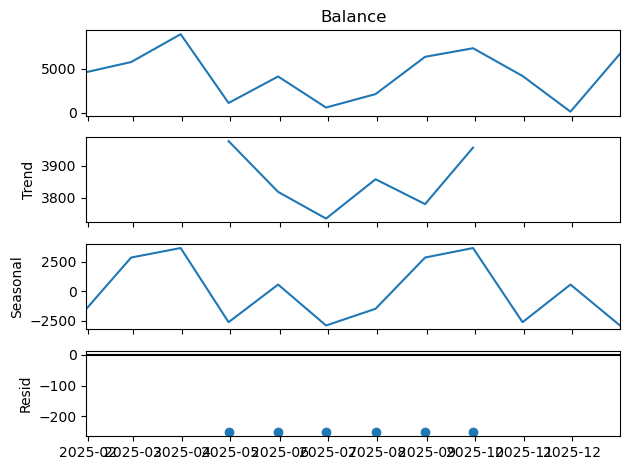

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Check available data points
if len(df_monthly) >= 24:
    season_period = 12  # Yearly seasonality
else:
    season_period = 6  # Half-yearly seasonality

# Decompose time series
result = seasonal_decompose(df_monthly, model="additive", period=season_period)
result.plot()
plt.show()

#### Inference
* The first graph shows the **original balance** over time.
* The second graph represents **trend decomposition**, indicating a possible **downward trend**.
* The third graph **seasonality**, which is visible but not strong.
* The residuals should ideally be random, but there seems to be some pattern, meaning a **better model is needed**.

In [42]:
# Grid search for best SARIMA order
p = q = range(0, 3)
P = Q = range(0, 3)
d = [0, 1]
D = [0, 1]
m = [season_period]

pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q, m))

best_aic = float("inf")
best_sarima_order = None
best_seasonal_order = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            model = SARIMAX(df_monthly, order=order, seasonal_order=seasonal_order)
            model_fit = model.fit()
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_sarima_order = order
                best_seasonal_order = seasonal_order
        except:
            continue

print(f"Best SARIMA Order: {best_sarima_order} with Seasonal Order: {best_seasonal_order} and AIC: {best_aic}")

Best SARIMA Order: (2, 0, 0) with Seasonal Order: (0, 1, 0, 6) and AIC: 6.0


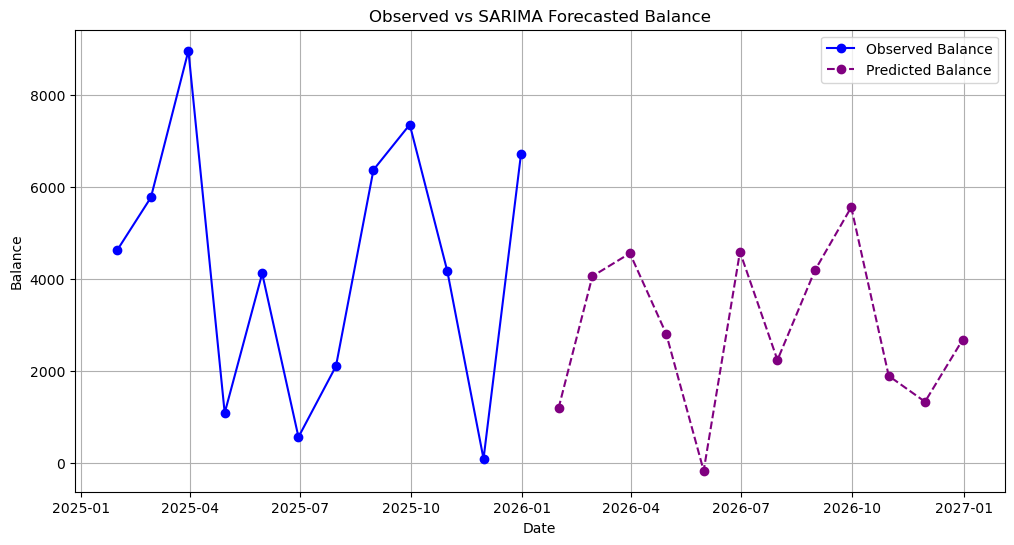

In [43]:
#df_cleaned['Datetime'] = pd.to_datetime(df_cleaned.index)
#df_cleaned.set_index('Datetime', inplace = True)

# Resample to monthly balance
#df_monthly = df_cleaned['Balance'].resample('ME').last()

# Check if there is enough data for seasonal differencing
'''
if len(df_monthly) < 24:
    print("Not enough data for seasonal differencing. Using non-seasonal ARIMA.")
    auto_model = pm.auto_arima(df_monthly, seasonal = False, stepwise = True, trace = True)
    best_order = auto_model.order
    seasonal_order = (0, 0, 0, 0) # No seasonality
else:
    auto_model = pm.auto_arima(df_monthly, seasonal = True, m = 12, stepwise = True, trace = True)
    best_order = auto_model.order
    seasonal_order = auto_model.seasonal_order
    
print(f"Optimal SARIMA Oder: {best_order}, Seasonal Order: {seasonal_order}")
'''
#best_sarima_order = (0, 0, 0)
#seasonal_order = (0, 1, 0, 12)

# Fit the model 
sarima_model = SARIMAX(df_monthly, order = best_order, seasonal_order = seasonal_order)
sarima_fit = sarima_model.fit()

# Forecast next 12 months
future_steps = 12
forecast = sarima_fit.forecast(steps = future_steps)

# Create futute dates
future_dates = pd.date_range(start = df_monthly.index[-1], periods = future_steps + 1, freq = 'ME')[1:]

# Convert forecast to DateFrame
forecast_df = pd.DataFrame({'Datetime': future_dates, 'Predicted_Balance': forecast.values})

# Plot the results
plt.figure(figsize = (12, 6))
plt.plot(df_monthly.index, df_monthly, color = "blue", label = "Observed Balance", marker = "o")
plt.plot(forecast_df['Datetime'], forecast_df['Predicted_Balance'], linestyle = "dashed", color = "purple", label = "Predicted Balance", marker = "o")

plt.xlabel("Date")
plt.ylabel("Balance")
plt.title("Observed vs SARIMA Forecasted Balance")
plt.legend()
plt.grid()
plt.show()

#### Inference
* The SARIMA forecast is **not flat** like in ARIMA.
* It captures fluctuations better, indicating that it recognizes **both trend and seasonal components**.
* This makes SARIMA a **better choice than ARIMA**.

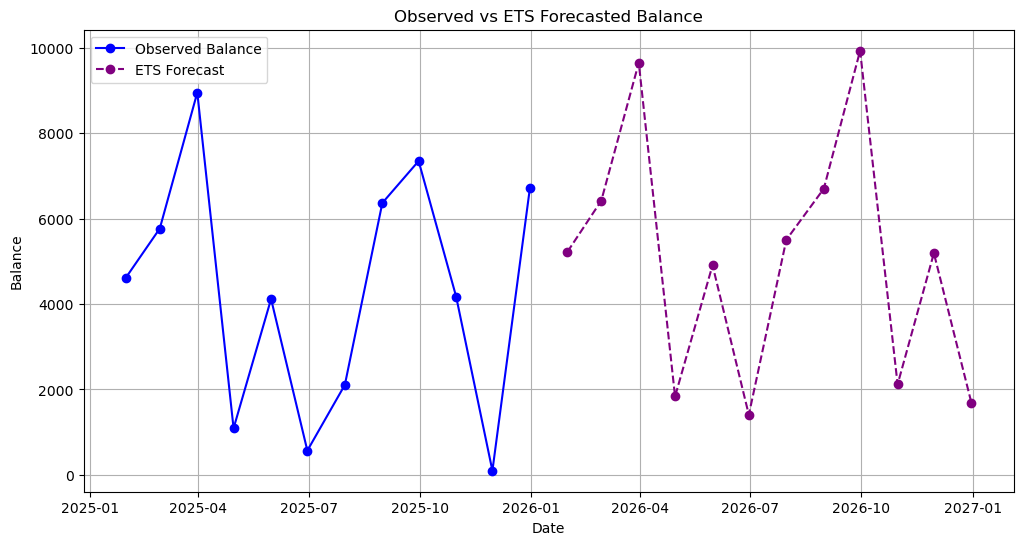

In [45]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Check seasonal period
if len(df_monthly) >= 24:
    season_periods = 12  # Yearly seasonality
elif len(df_monthly) >= 12:
    season_periods = 6  # Half-yearly seasonality
else:
    season_periods = None  # No seasonality

# Fit ETS model (Holt-Winters)
if season_periods:
    ets_model = ExponentialSmoothing(df_monthly, trend="add", seasonal="add", seasonal_periods=season_periods)
else:
    ets_model = ExponentialSmoothing(df_monthly, trend="add", seasonal=None)

ets_fit = ets_model.fit()

# Forecast
future_steps = 12
ets_forecast = ets_fit.forecast(steps=future_steps)
future_dates = pd.date_range(start=df_monthly.index[-1], periods=future_steps+1, freq='ME')[1:]

# Convert forecast to DataFrame
ets_forecast_df = pd.DataFrame({'Datetime': future_dates, 'Predicted_Balance': ets_forecast.values})

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df_monthly.index, df_monthly, color="blue", label="Observed Balance", marker="o")
plt.plot(ets_forecast_df['Datetime'], ets_forecast_df['Predicted_Balance'], linestyle="dashed", color="purple", label="ETS Forecast", marker="o")

plt.xlabel("Date")
plt.ylabel("Balance")
plt.title("Observed vs ETS Forecasted Balance")
plt.legend()
plt.grid()
plt.show()


#### Inference
* The ETS model produces a forecast that **closely follows the observed balance**.
* The **ETS forecast adapts well to fluctuations**, making it a stronger candidate.
* Since ETS is an exponential smoothing model, it **prioritizes recent trends**, making it highly adaptive.

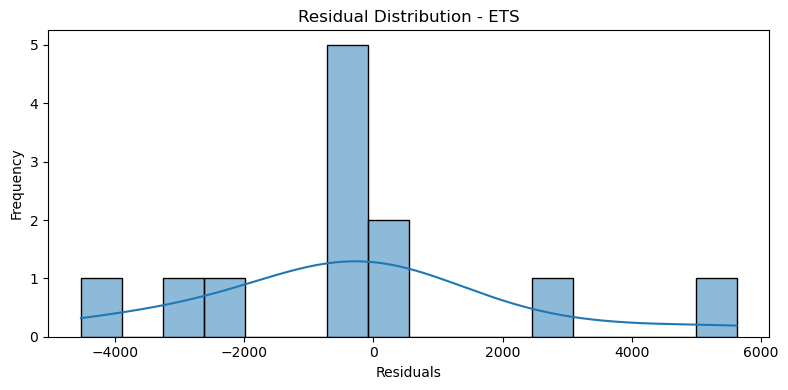

In [47]:
# Residual Calculation
# Actual vs Fitted on training data
fitted_values = ets_fit.fittedvalues
residuals_ets = df_monthly - fitted_values

# Plot Residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals_ets.dropna(), kde=True)
plt.title("Residual Distribution - ETS")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Final Model Efficiency Comparison
| **Model** | **Performance** | **Strengths** | **Weaknesses** |
|-----------|-----------------|---------------|-----------------|
| **ARIMA** | Poor | Works well for stationary series | Cannot handle trend/seasonality well|
| **SARIMA** | Good | Captures trend & seasonality | Needs more data for parameter tuning |
| **ETS** | Best | Adapts well to fluctuations | Can be sensitive to noise |


### Real World Application in Banking Sector
1. **Forecasting Customer Balances**
   * Banks need to predict **monthly balance trends** for liquidity management.
   * An accurate forecast helps ensure eough cash reserves to meet withdrawals.
2. **Loan & Credit Risk Management**
   * Predicting an individual's balance helps banks **assess creditworthiness**.
   * If a balance is predicted to decline, banks can **proactively offer financial support** or **adjust credit limits**.  
3. **Fraud Detection**
   * **Unusual deviations in balance trends** can indicate **fradulent activities**.
   * If a customer's balance fluctuates abnormally, the system can trigger an **alert**.
4. **Investment & Revenue Optimization**
    * Banks use balance forecasts to decide **how uch capital to invest**.
    * Forecasting deposit trends helps them **adjust interest rates** to attract or retain customers.
5. **Personalized Banking Recomendations**
   * If a customer's balance is forecasted to drop, the bank can suggest **saving plans** or **short-term loans**.
   * If an increase is predicted, they can recommend **investment products**. 